In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv("../data/credit_card_fraud_10k.csv")

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 10000
Columns: 10


In [3]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 781.4 KB


In [5]:
df.columns.tolist()

['transaction_id',
 'amount',
 'transaction_hour',
 'merchant_category',
 'foreign_transaction',
 'location_mismatch',
 'device_trust_score',
 'velocity_last_24h',
 'cardholder_age',
 'is_fraud']

In [6]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [7]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [10]:
df["is_fraud"].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

In [11]:
df["is_fraud"].value_counts(normalize=True) * 100

is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64

In [12]:
for i, col in enumerate(df.columns):
    print(i + 1, col)

1 transaction_id
2 amount
3 transaction_hour
4 merchant_category
5 foreign_transaction
6 location_mismatch
7 device_trust_score
8 velocity_last_24h
9 cardholder_age
10 is_fraud


In [13]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDuplicate transaction IDs:")
print(df["transaction_id"].duplicated().sum())

Dataset shape: (10000, 10)

Missing values:
transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

Duplicate rows:
0

Duplicate transaction IDs:
0


In [14]:
fraud_counts = df["is_fraud"].value_counts()

print("Transaction counts:")
print(fraud_counts)

Transaction counts:
is_fraud
0    9849
1     151
Name: count, dtype: int64


In [15]:
fraud_percentage = df["is_fraud"].value_counts(normalize=True) * 100

print("Transaction percentage:")
print(fraud_percentage.round(2))

Transaction percentage:
is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


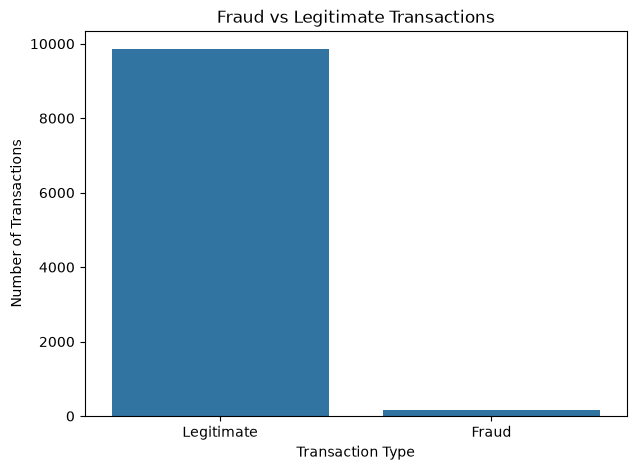

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="is_fraud"
)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.show()

In [17]:
fraud_rate = df["is_fraud"].mean() * 100

print(f"Overall fraud rate: {fraud_rate:.2f}%")

Overall fraud rate: 1.51%


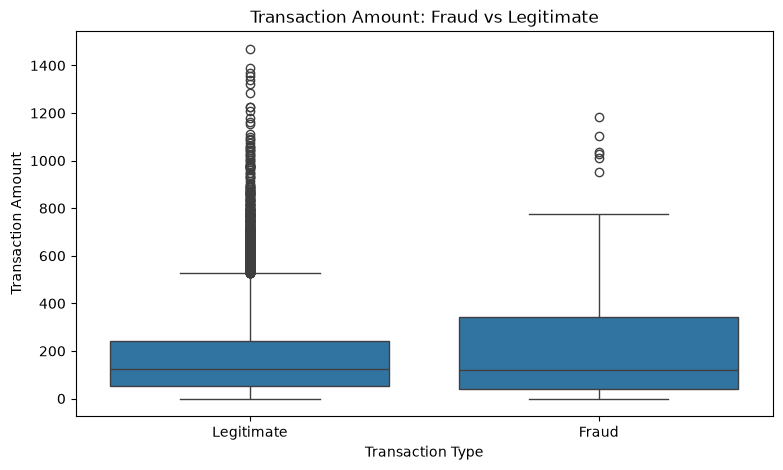

In [18]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="amount"
)

plt.title("Transaction Amount: Fraud vs Legitimate")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.show()

In [19]:
df.groupby("is_fraud")["amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
is_fraud,,,,,
0,9849,175.333015,122.11,0.00,1471.04
1,151,216.182980,118.94,0.11,1185.07


In [20]:
merchant_fraud = pd.crosstab(
    df["merchant_category"],
    df["is_fraud"],
    normalize="index"
) * 100

merchant_fraud

is_fraud,0,1
merchant_category,,
Clothing,98.829268,1.170732
Electronics,98.751950,1.248050
Food,98.327759,1.672241
Grocery,97.993827,2.006173
Travel,98.542714,1.457286


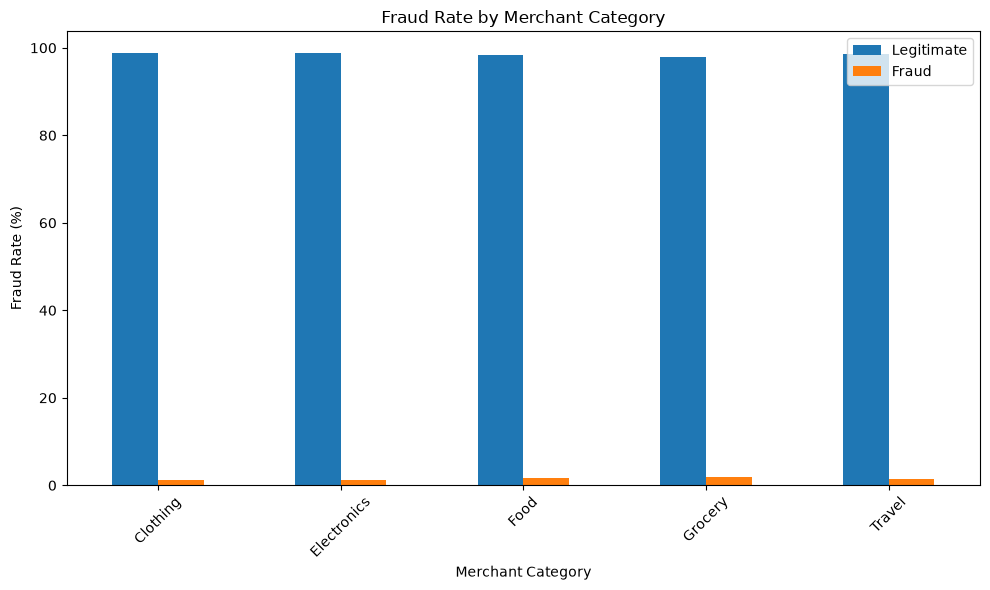

In [21]:
merchant_fraud.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Fraud Rate by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.legend(["Legitimate", "Fraud"])

plt.tight_layout()
plt.show()

In [22]:
print(fraud_counts)

is_fraud
0    9849
1     151
Name: count, dtype: int64


In [23]:
df.groupby("is_fraud")["amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
is_fraud,,,,,
0,9849,175.333015,122.11,0.00,1471.04
1,151,216.182980,118.94,0.11,1185.07


In [24]:
foreign_fraud = pd.crosstab(
    df["foreign_transaction"],
    df["is_fraud"],
    normalize="index"
) * 100

print(foreign_fraud)

is_fraud                     0         1
foreign_transaction                     
0                    99.235203  0.764797
1                    91.615542  8.384458


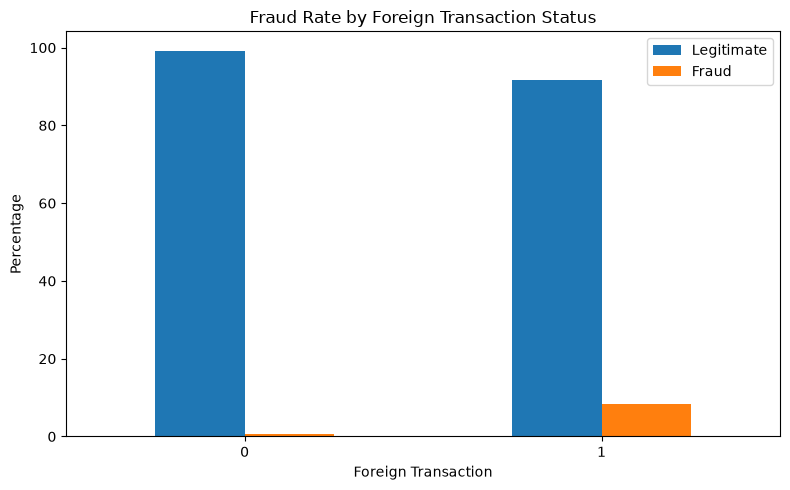

In [25]:
foreign_fraud.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Fraud Rate by Foreign Transaction Status")
plt.xlabel("Foreign Transaction")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["Legitimate", "Fraud"])
plt.tight_layout()
plt.show()

In [26]:
location_fraud = pd.crosstab(
    df["location_mismatch"],
    df["is_fraud"],
    normalize="index"
) * 100

print(location_fraud)

is_fraud                   0         1
location_mismatch                     
0                  99.135951  0.864049
1                  91.598600  8.401400


In [27]:
df.groupby("is_fraud")["device_trust_score"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
is_fraud,,,,,
0,9849,62.165804,62.0,25,99
1,151,37.867550,32.0,25,99


In [28]:
print(foreign_fraud)

is_fraud                     0         1
foreign_transaction                     
0                    99.235203  0.764797
1                    91.615542  8.384458


In [29]:
print(location_fraud)

is_fraud                   0         1
location_mismatch                     
0                  99.135951  0.864049
1                  91.598600  8.401400


In [30]:
df.groupby("is_fraud")["device_trust_score"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
is_fraud,,,,,
0,9849,62.165804,62.0,25,99
1,151,37.867550,32.0,25,99


## Business Insights

### Foreign Transactions
Foreign transactions show a substantially higher fraud rate than domestic transactions (8.38% vs. 0.76%). This suggests that foreign transaction status may be an important risk signal for transaction monitoring.

### Location Mismatch
Transactions with a location mismatch have a significantly higher fraud rate than transactions without a mismatch (8.40% vs. 0.86%). Location inconsistency appears to be a strong indicator of potential fraudulent activity.

### Device Trust
Fraudulent transactions have a substantially lower average device trust score than legitimate transactions (37.87 vs. 62.17). This suggests that device-level trust can be an important feature when assessing transaction risk.

### Transaction Amount
Fraudulent transactions have a higher average transaction amount (216.18 vs. 175.33), but their median amounts are similar (118.94 vs. 122.11). This indicates that the difference in average amount may be influenced by a relatively small number of high-value transactions.

In [31]:
fraud_by_hour = (
    df.groupby("transaction_hour")["is_fraud"]
    .mean()
    .mul(100)
)

fraud_by_hour

transaction_hour
0     8.872902
1     8.000000
2     5.974026
3     6.352941
4     0.260417
5     0.477327
6     0.484262
7     0.000000
8     0.707547
9     0.234742
10    0.279330
11    0.519481
12    0.000000
13    0.476190
14    0.218341
15    0.462963
16    0.000000
17    0.466200
18    0.227790
19    0.950119
20    0.477327
21    0.236407
22    0.000000
23    0.715990
Name: is_fraud, dtype: float64

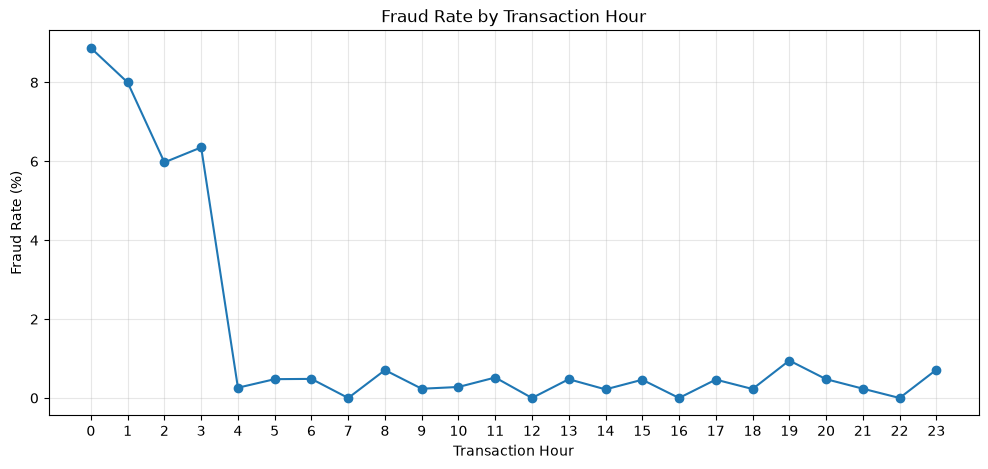

In [32]:
plt.figure(figsize=(12, 5))

fraud_by_hour.plot(marker="o")

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()

In [33]:
top_risk_hours = (
    fraud_by_hour
    .sort_values(ascending=False)
    .head(5)
)

print("Top 5 hours by fraud rate:")
print(top_risk_hours)

Top 5 hours by fraud rate:
transaction_hour
0     8.872902
1     8.000000
3     6.352941
2     5.974026
19    0.950119
Name: is_fraud, dtype: float64


In [34]:
velocity_analysis = df.groupby("is_fraud")["velocity_last_24h"].agg(
    ["count", "mean", "median", "min", "max"]
)

velocity_analysis

,count,mean,median,min,max
is_fraud,,,,,
0,9849,1.990557,2.0,0,9
1,151,3.205298,3.0,0,7


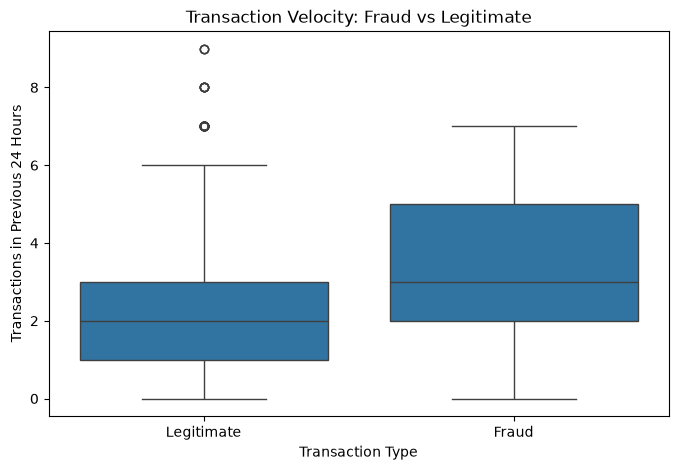

In [35]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="velocity_last_24h"
)

plt.title("Transaction Velocity: Fraud vs Legitimate")
plt.xlabel("Transaction Type")
plt.ylabel("Transactions in Previous 24 Hours")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.show()

In [36]:
velocity_bins = pd.cut(
    df["velocity_last_24h"],
    bins=[0, 5, 10, 20, 30, 50, 100],
    include_lowest=True
)

velocity_fraud_rate = (
    df.groupby(velocity_bins, observed=False)["is_fraud"]
    .mean()
    .mul(100)
)

print("Fraud rate by transaction velocity:")
print(velocity_fraud_rate)

Fraud rate by transaction velocity:
velocity_last_24h
(-0.001, 5.0]    1.385211
(5.0, 10.0]      8.241758
(10.0, 20.0]          NaN
(20.0, 30.0]          NaN
(30.0, 50.0]          NaN
(50.0, 100.0]         NaN
Name: is_fraud, dtype: float64


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [6]:
df = pd.read_csv("../data/credit_card_fraud_10k.csv")

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 10000
Columns: 10


In [7]:
df["transaction_hour"] = pd.to_numeric(
    df["transaction_hour"],
    errors="coerce"
)

fraud_by_hour = (
    df.dropna(subset=["transaction_hour"])
      .groupby("transaction_hour")["is_fraud"]
      .mean()
      .mul(100)
      .sort_index()
)

print(fraud_by_hour)

transaction_hour
0     8.872902
1     8.000000
2     5.974026
3     6.352941
4     0.260417
5     0.477327
6     0.484262
7     0.000000
8     0.707547
9     0.234742
10    0.279330
11    0.519481
12    0.000000
13    0.476190
14    0.218341
15    0.462963
16    0.000000
17    0.466200
18    0.227790
19    0.950119
20    0.477327
21    0.236407
22    0.000000
23    0.715990
Name: is_fraud, dtype: float64


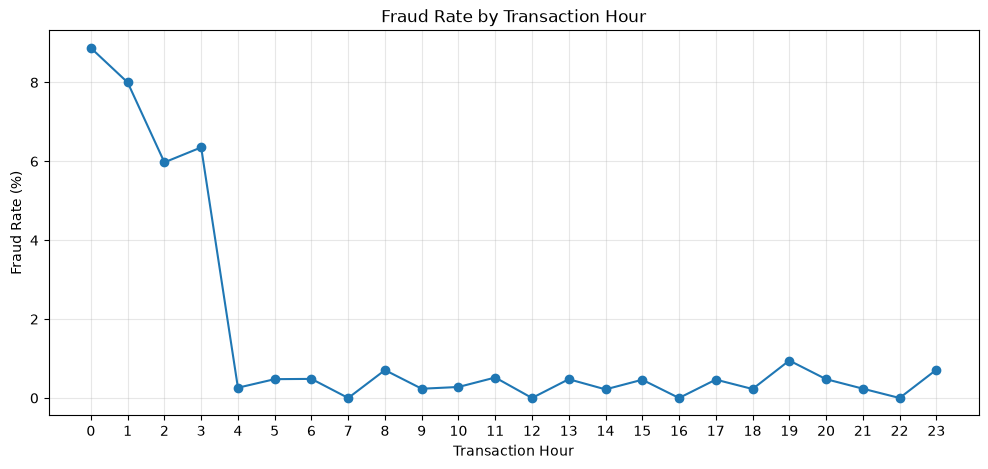

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    fraud_by_hour.index,
    fraud_by_hour.values,
    marker="o"
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()

In [9]:
top_risk_hours = (
    fraud_by_hour
    .sort_values(ascending=False)
    .head(5)
)

print("Top 5 hours by fraud rate:")
print(top_risk_hours)

Top 5 hours by fraud rate:
transaction_hour
0     8.872902
1     8.000000
3     6.352941
2     5.974026
19    0.950119
Name: is_fraud, dtype: float64


In [10]:
velocity_analysis = (
    df.groupby("is_fraud")["velocity_last_24h"]
      .agg(["count", "mean", "median", "min", "max"])
)

print(velocity_analysis)

          count      mean  median  min  max
is_fraud                                   
0          9849  1.990557     2.0    0    9
1           151  3.205298     3.0    0    7


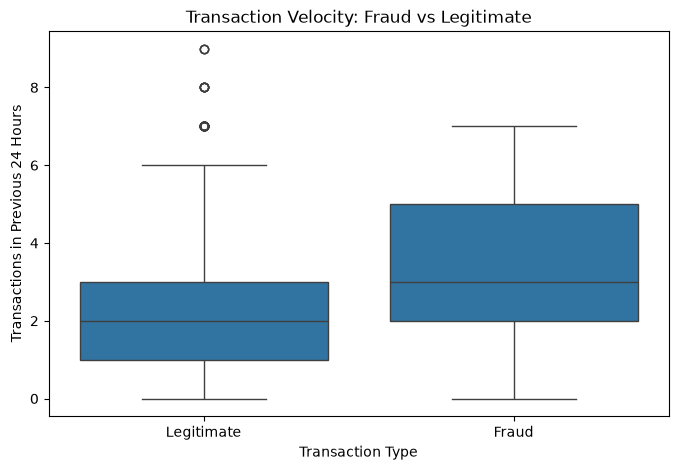

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="velocity_last_24h"
)

plt.title("Transaction Velocity: Fraud vs Legitimate")
plt.xlabel("Transaction Type")
plt.ylabel("Transactions in Previous 24 Hours")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.show()

In [12]:
velocity_bins = pd.cut(
    df["velocity_last_24h"],
    bins=[0, 5, 10, 20, 30, 50, 100],
    include_lowest=True
)

velocity_fraud_rate = (
    df.groupby(velocity_bins, observed=False)["is_fraud"]
      .mean()
      .mul(100)
)

print("Fraud rate by transaction velocity:")
print(velocity_fraud_rate)

Fraud rate by transaction velocity:
velocity_last_24h
(-0.001, 5.0]    1.385211
(5.0, 10.0]      8.241758
(10.0, 20.0]          NaN
(20.0, 30.0]          NaN
(30.0, 50.0]          NaN
(50.0, 100.0]         NaN
Name: is_fraud, dtype: float64


## Behavioral Risk Insights

### Transaction Hour
Fraud rates vary considerably across transaction hours. The highest observed fraud rates occur during the early morning, particularly at 00:00 (8.87%), 01:00 (8.00%), 03:00 (6.35%), and 02:00 (5.97%). This suggests that transaction timing may be a useful risk signal for fraud monitoring in this dataset.

### Transaction Velocity
Transactions associated with 5–10 transactions during the previous 24 hours have an observed fraud rate of 8.24%, compared with 1.39% for transactions associated with 0–5 transactions. This indicates that elevated transaction velocity may be associated with increased fraud risk.

The dataset does not contain observations above 10 transactions in the previous 24 hours, so conclusions cannot be extended to higher velocity levels.

In [13]:
merchant_analysis = (
    df.groupby("merchant_category")
      .agg(
          transactions=("transaction_id", "count"),
          fraud_transactions=("is_fraud", "sum"),
          fraud_rate=("is_fraud", "mean")
      )
)

merchant_analysis["fraud_rate"] = (
    merchant_analysis["fraud_rate"] * 100
)

merchant_analysis = merchant_analysis.sort_values(
    "fraud_rate",
    ascending=False
)

merchant_analysis

,transactions,fraud_transactions,fraud_rate
merchant_category,,,
Grocery,1944,39,2.006173
Food,2093,35,1.672241
Travel,1990,29,1.457286
Electronics,1923,24,1.248050
Clothing,2050,24,1.170732


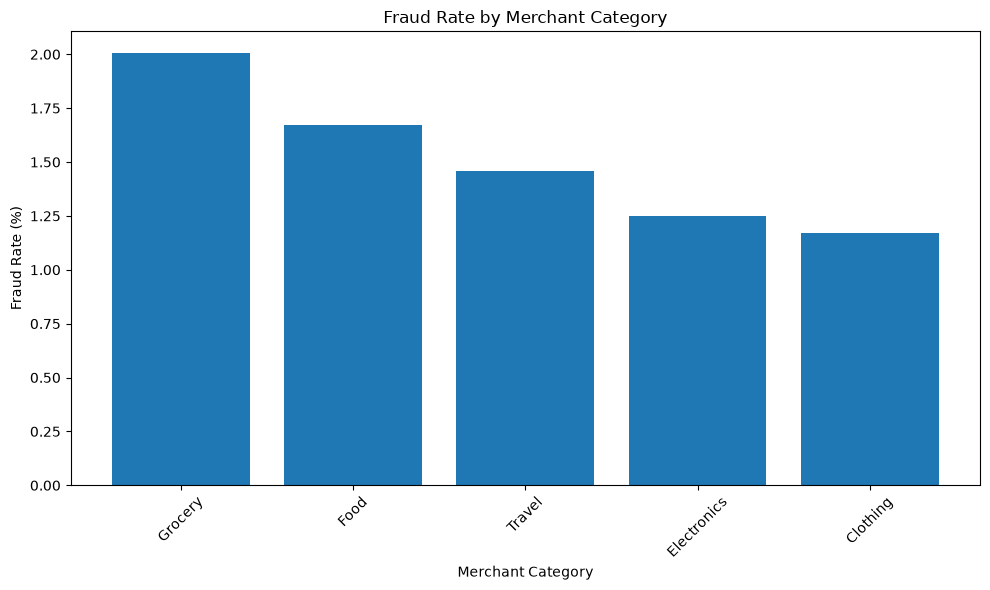

In [14]:
plt.figure(figsize=(10, 6))

plt.bar(
    merchant_analysis.index.astype(str),
    merchant_analysis["fraud_rate"]
)

plt.title("Fraud Rate by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [15]:
print("Highest-risk merchant categories:")
print(
    merchant_analysis[
        ["transactions", "fraud_transactions", "fraud_rate"]
    ].head(5)
)

Highest-risk merchant categories:
                   transactions  fraud_transactions  fraud_rate
merchant_category                                              
Grocery                    1944                  39    2.006173
Food                       2093                  35    1.672241
Travel                     1990                  29    1.457286
Electronics                1923                  24    1.248050
Clothing                   2050                  24    1.170732
